# XGBoost — Feature Selection

**Prerequisite:** Run `data/01_build_features.ipynb` to generate `data/latest_features.jsonl`.

**Goal:** Find the optimal feature set and hyperparameters for XGBoost.

**Method:** Feature importance ranking + hyperparameter grid search + probability calibration.
Importance ranking is used for feature selection (same as RF). Grid search and calibration are
additional steps needed because XGBoost has more tunable parameters than RF.

**Metric:** Per-snapshot accuracy (same as LR and RF notebooks).

**Output:** `data/optimal_features_xgb.json` with features, hyperparameters, and calibration flag.


In [1]:
import sys

sys.path.insert(0, str(__import__("pathlib").Path.cwd().parent))

import json
import random
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

FEATURES_PATH = Path("../../data/latest_features.jsonl")
LR_FEATURES_PATH = Path("../../data/optimal_features_lr.json")
RF_FEATURES_PATH = Path("../../data/optimal_features_rf.json")
DB_PATH = Path("../../data/collection.db")
MAX_BID = 0.85
WARM_UP = 21

## 1. Load data and train/val split

In [2]:
rows = []
with open(FEATURES_PATH) as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["target"] = (df["outcome"] == "UP").astype(int)

NON_FEAT = {
    "candle_id",
    "session",
    "timestamp",
    "elapsed_pct",
    "btc_price",
    "up_best_bid",
    "up_best_ask",
    "up_bid_depth",
    "up_ask_depth",
    "down_best_bid",
    "down_best_ask",
    "down_bid_depth",
    "down_ask_depth",
    "market_volume",
    "outcome",
    "target",
}
all_feat_cols = sorted([c for c in df.columns if c not in NON_FEAT])
df[all_feat_cols] = df[all_feat_cols].fillna(0.0)

candle_ids = df["candle_id"].unique()
split_idx = int(len(candle_ids) * 0.8)
train_ids = set(candle_ids[:split_idx])
val_ids = set(candle_ids[split_idx:])

df_train = df[df["candle_id"].isin(train_ids)]
df_val = df[df["candle_id"].isin(val_ids)]

scaler = StandardScaler()
X_train_all = scaler.fit_transform(df_train[all_feat_cols].values)
y_train = df_train["target"].values
X_val_all = scaler.transform(df_val[all_feat_cols].values)
y_val = df_val["target"].values

print(f"Features: {len(all_feat_cols)}")
print(f"Train: {len(df_train):,} rows, {df_train['candle_id'].nunique()} candles")
print(f"Val:   {len(df_val):,} rows, {df_val['candle_id'].nunique()} candles")

Features: 60
Train: 53,236 rows, 1100 candles
Val:   12,917 rows, 276 candles


## 2. Feature importance ranking with XGBoost

In [3]:
# Train baseline XGBoost on all features to get importance ranking
base_xgb = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1,
)
base_xgb.fit(X_train_all, y_train)

importances = base_xgb.feature_importances_
feat_imp = sorted(zip(all_feat_cols, importances, strict=False), key=lambda x: -x[1])

print(f"{'Feature':<35} {'Importance':>10}")
print("-" * 47)
for name, imp in feat_imp[:30]:
    bar = "█" * int(imp / feat_imp[0][1] * 30)
    print(f"  {name:<33} {imp:>10.4f}  {bar}")

Feature                             Importance
-----------------------------------------------
  down_risk_reward                      0.1875  ██████████████████████████████
  up_risk_reward                        0.1577  █████████████████████████
  up_implied_probability                0.0495  ███████
  down_implied_probability              0.0450  ███████
  rr_spread                             0.0245  ███
  multi_candle_return_6                 0.0172  ██
  volume_momentum                       0.0160  ██
  volume_trend                          0.0158  ██
  bollinger_pct_b                       0.0153  ██
  return_autocorrelation                0.0153  ██
  regime_score                          0.0150  ██
  trend_consistency                     0.0149  ██
  streak_magnitude                      0.0148  ██
  stochastic_k                          0.0148  ██
  prior_return                          0.0148  ██
  prior_reversal_rate                   0.0147  ██
  rsi                      

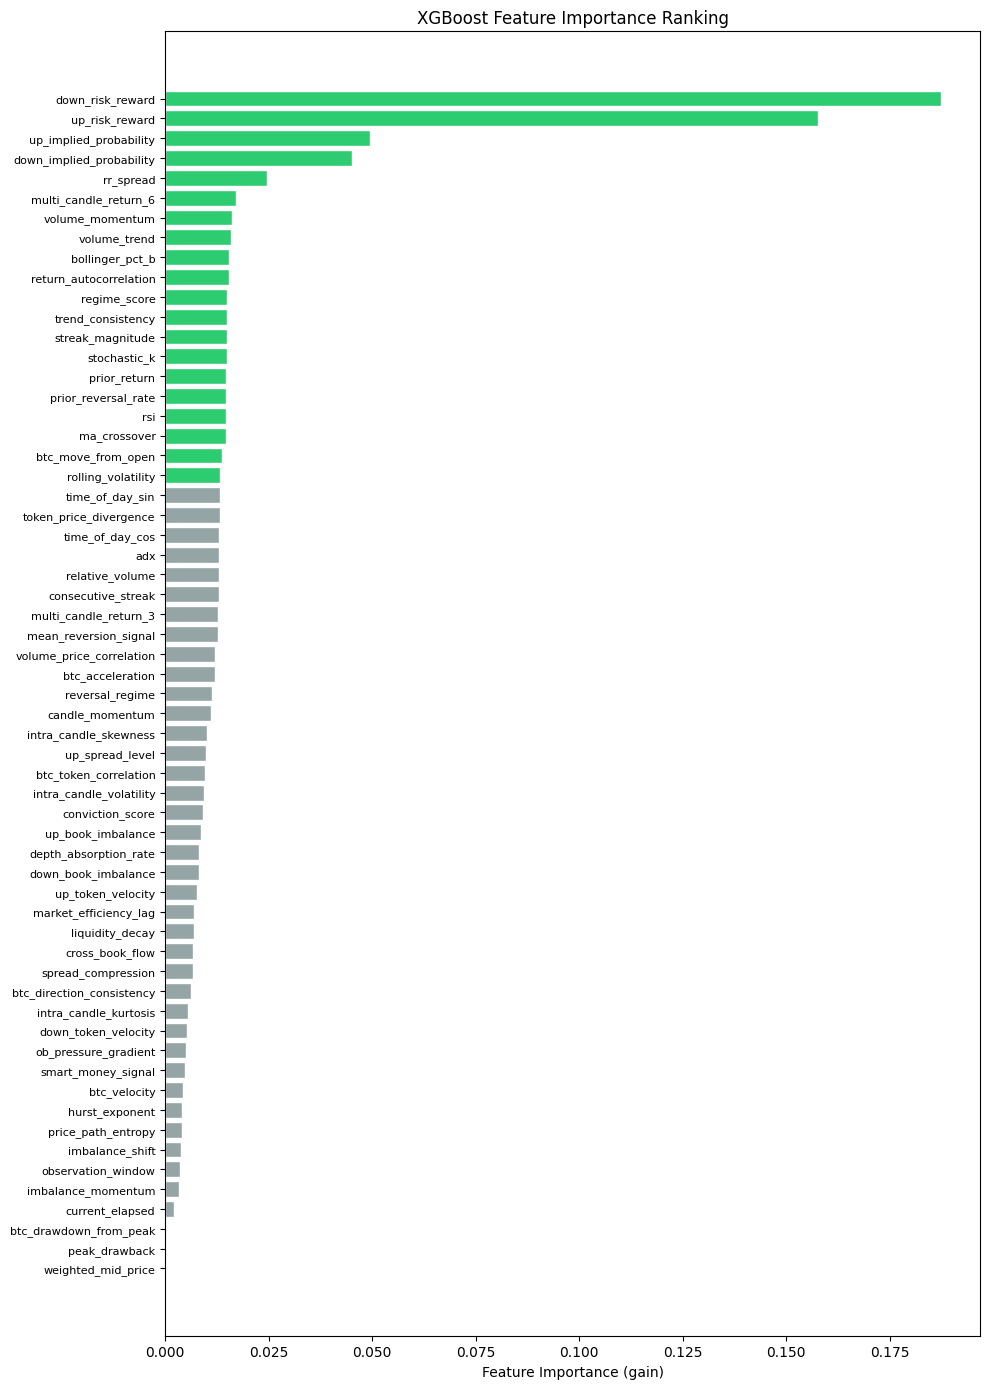

In [4]:
names = [f[0] for f in feat_imp]
imps = [f[1] for f in feat_imp]

fig, ax = plt.subplots(figsize=(10, 14))
colors = ["#2ecc71" if i < 20 else "#95a5a6" for i in range(len(names))]
ax.barh(range(len(names)), imps, color=colors, edgecolor="white")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("XGBoost Feature Importance Ranking")
plt.tight_layout()
plt.show()

## 3. Find optimal feature count

In [5]:
ranked_features = [name for name, _ in feat_imp]
ranked_indices = [all_feat_cols.index(name) for name in ranked_features]

top_n_results = []
print(f"{'Top N':<8} {'Snap Acc':>9} {'Brier':>8}")
print("-" * 28)

for n in list(range(5, len(all_feat_cols) + 1, 5)) + [len(all_feat_cols)]:
    idx = ranked_indices[:n]
    model = xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
    )
    model.fit(X_train_all[:, idx], y_train)
    probs = model.predict_proba(X_val_all[:, idx])[:, 1]
    snap_acc = accuracy_score(y_val, (probs >= 0.5).astype(int))
    brier = brier_score_loss(y_val, probs)
    top_n_results.append((n, snap_acc, brier))
    print(f"  {n:<6} {snap_acc * 100:>8.1f}% {brier:>8.4f}")

# Best N by snapshot accuracy
best_n, best_snap, best_brier = max(top_n_results, key=lambda x: x[1])
print(f"\nBest: top {best_n} features → {best_snap * 100:.1f}% accuracy, Brier={best_brier:.4f}")

optimal_names = ranked_features[:best_n]
optimal_indices = ranked_indices[:best_n]
print(f"Optimal features: {optimal_names}")

Top N     Snap Acc    Brier
----------------------------
  5          75.2%   0.1583
  10         71.5%   0.1792
  15         70.9%   0.1862
  20         71.0%   0.1845
  25         69.2%   0.1919
  30         72.4%   0.1744
  35         71.2%   0.1805
  40         71.7%   0.1782
  45         72.5%   0.1760
  50         72.2%   0.1750
  55         72.2%   0.1778
  60         71.1%   0.1820
  60         71.1%   0.1820

Best: top 5 features → 75.2% accuracy, Brier=0.1583
Optimal features: ['down_risk_reward', 'up_risk_reward', 'up_implied_probability', 'down_implied_probability', 'rr_spread']


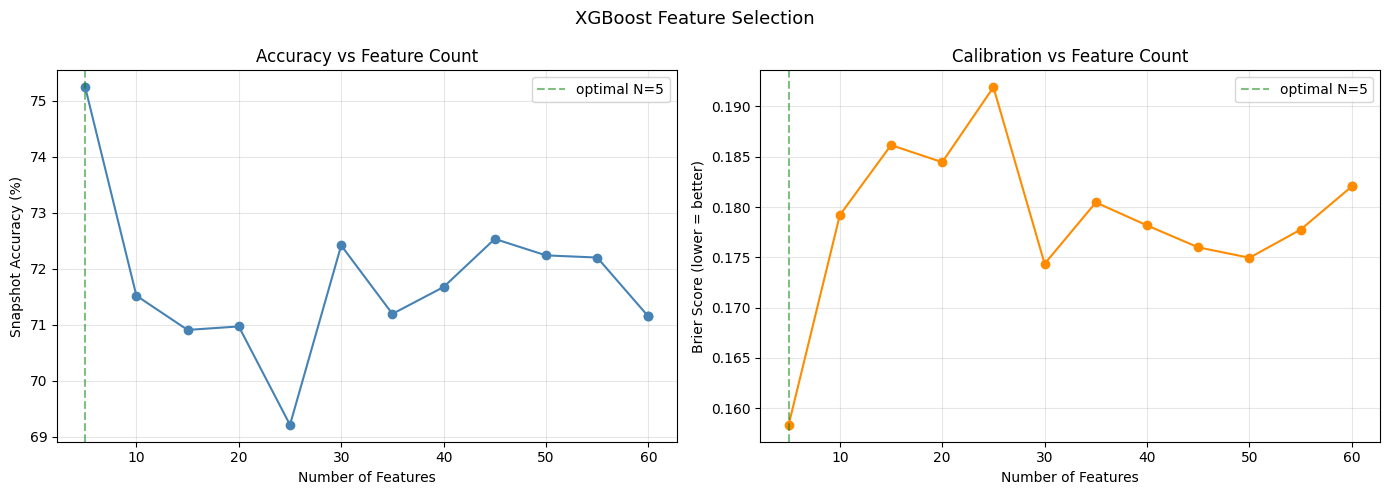

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ns = [r[0] for r in top_n_results]
snap_accs = [r[1] * 100 for r in top_n_results]
briers = [r[2] for r in top_n_results]

axes[0].plot(ns, snap_accs, "o-", color="steelblue")
axes[0].axvline(best_n, color="green", linestyle="--", alpha=0.5, label=f"optimal N={best_n}")
axes[0].set_xlabel("Number of Features")
axes[0].set_ylabel("Snapshot Accuracy (%)")
axes[0].set_title("Accuracy vs Feature Count")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ns, briers, "o-", color="darkorange")
axes[1].axvline(best_n, color="green", linestyle="--", alpha=0.5, label=f"optimal N={best_n}")
axes[1].set_xlabel("Number of Features")
axes[1].set_ylabel("Brier Score (lower = better)")
axes[1].set_title("Calibration vs Feature Count")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("XGBoost Feature Selection", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Hyperparameter tuning with early stopping

In [7]:
X_train_opt = X_train_all[:, optimal_indices]
X_val_opt = X_val_all[:, optimal_indices]

param_grid = {
    "learning_rate": [0.01, 0.03, 0.05],
    "max_depth": [3, 4, 6],
    "min_child_weight": [10, 15, 20],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.6, 0.7, 0.8],
}

grid = list(ParameterGrid(param_grid))
print(f"Testing {len(grid)} hyperparameter combinations...")

results = []
for _i, params in enumerate(tqdm(grid, desc="Tuning")):
    model = xgb.XGBClassifier(
        n_estimators=1000,
        early_stopping_rounds=30,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1,
        **params,
    )
    model.fit(
        X_train_opt,
        y_train,
        eval_set=[(X_val_opt, y_val)],
        verbose=False,
    )
    probs = model.predict_proba(X_val_opt)[:, 1]
    acc = accuracy_score(y_val, (probs >= 0.5).astype(int))
    brier = brier_score_loss(y_val, probs)
    n_trees = model.best_iteration + 1
    results.append({**params, "accuracy": acc, "brier": brier, "n_estimators": n_trees})

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)
print("\nTop 10 configurations:")
print(results_df.head(10).to_string(index=False))

best_params = results_df.iloc[0].to_dict()
best_acc = best_params.pop("accuracy")
best_brier_tuned = best_params.pop("brier")
best_n_est = int(best_params.pop("n_estimators"))
# Cast types: max_depth, min_child_weight, n_estimators must be int for XGBoost
INT_PARAMS = {"max_depth", "min_child_weight", "n_estimators"}
best_params = {k: int(v) if k in INT_PARAMS else float(v) for k, v in best_params.items()}
best_params["n_estimators"] = best_n_est

print(f"\nBest: accuracy={best_acc * 100:.1f}%, Brier={best_brier_tuned:.4f}")
print(f"Params: {best_params}")

Testing 162 hyperparameter combinations...


Tuning: 100%|██████████| 162/162 [01:08<00:00,  2.38it/s]


Top 10 configurations:
 colsample_bytree  learning_rate  max_depth  min_child_weight  subsample  accuracy    brier  n_estimators
              0.7           0.03          3                20        0.7  0.753348 0.157657           199
              0.7           0.03          3                15        0.7  0.753348 0.157660           199
              0.6           0.03          3                20        0.7  0.753348 0.157657           199
              0.6           0.03          3                15        0.7  0.753348 0.157660           199
              0.8           0.05          3                20        0.7  0.753271 0.157782           149
              0.8           0.03          3                15        0.8  0.753271 0.157747           196
              0.8           0.03          3                20        0.8  0.753271 0.157744           197
              0.8           0.03          4                15        0.7  0.753271 0.157679           183
              0.6     

## 5. Probability calibration

In [8]:
# Train the best model
best_xgb = xgb.XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1,
    **best_params,
)
best_xgb.fit(X_train_opt, y_train)

# Raw probabilities
raw_probs = best_xgb.predict_proba(X_val_opt)[:, 1]

# Calibrate with isotonic regression (cv=3 on training data)
cal_xgb = CalibratedClassifierCV(best_xgb, method="isotonic", cv=3)
cal_xgb.fit(X_train_opt, y_train)
cal_probs = cal_xgb.predict_proba(X_val_opt)[:, 1]

# Compare
raw_acc = accuracy_score(y_val, (raw_probs >= 0.5).astype(int))
cal_acc = accuracy_score(y_val, (cal_probs >= 0.5).astype(int))
raw_brier = brier_score_loss(y_val, raw_probs)
cal_brier = brier_score_loss(y_val, cal_probs)
raw_logloss = log_loss(y_val, raw_probs)
cal_logloss = log_loss(y_val, cal_probs)

print(f"{'Metric':<20} {'Raw':>10} {'Calibrated':>12}")
print("-" * 44)
print(f"{'Accuracy':<20} {raw_acc * 100:>9.1f}% {cal_acc * 100:>11.1f}%")
print(f"{'Brier Score':<20} {raw_brier:>10.4f} {cal_brier:>12.4f}")
print(f"{'Log Loss':<20} {raw_logloss:>10.4f} {cal_logloss:>12.4f}")

Metric                      Raw   Calibrated
--------------------------------------------
Accuracy                  75.3%        75.3%
Brier Score              0.1577       0.1578
Log Loss                 0.4678       0.4682


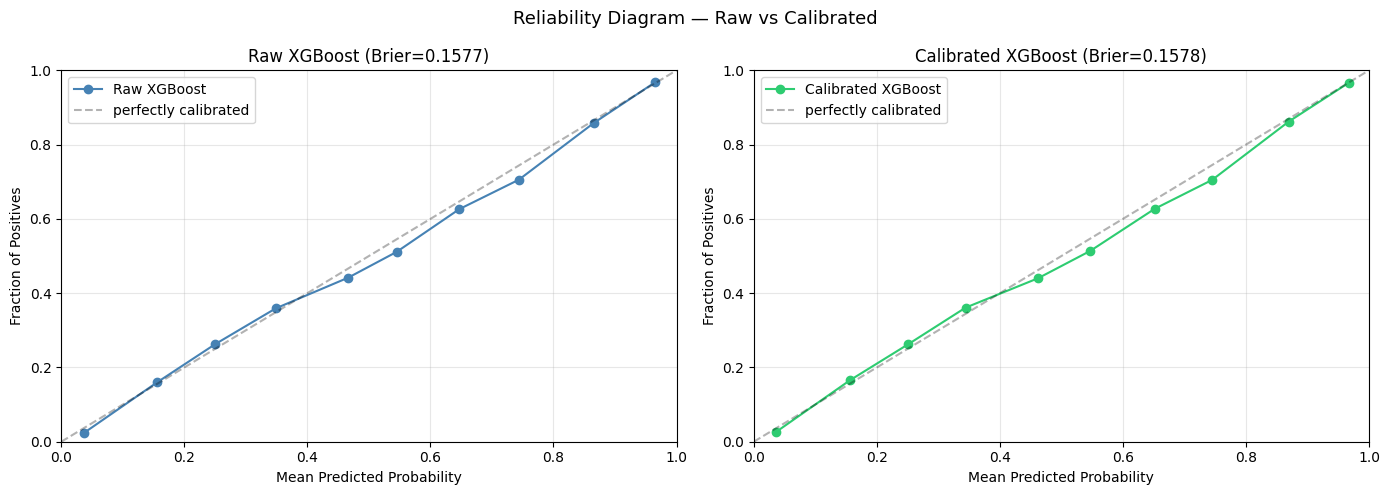

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, probs, label, color in [
    (axes[0], raw_probs, "Raw XGBoost", "steelblue"),
    (axes[1], cal_probs, "Calibrated XGBoost", "#2ecc71"),
]:
    fraction_pos, mean_predicted = calibration_curve(y_val, probs, n_bins=10)
    ax.plot(mean_predicted, fraction_pos, "o-", color=color, label=label)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="perfectly calibrated")
    ax.set_xlabel("Mean Predicted Probability")
    ax.set_ylabel("Fraction of Positives")
    brier = brier_score_loss(y_val, probs)
    ax.set_title(f"{label} (Brier={brier:.4f})")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle("Reliability Diagram — Raw vs Calibrated", fontsize=13)
plt.tight_layout()
plt.show()

### Export optimal XGBoost features

Save to `data/optimal_features_xgb.json` for all downstream notebooks.

In [10]:
config = {
    "model": "xgboost",
    "features": optimal_names,
    "n_features": best_n,
    "accuracy": round(best_acc, 4),
    "selection_method": "importance_ranking",
    "hyperparameters": best_params,
    "calibrated": True,
    "source": "data/latest_features.jsonl",
    "created_at": datetime.now(UTC).isoformat(),
}

out_path = Path("../../data/optimal_features_xgb.json")
with open(out_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"Saved {config['n_features']} XGBoost features to {out_path}")
print(f"Accuracy: {config['accuracy'] * 100:.2f}%")
print(f"Hyperparameters: {config['hyperparameters']}")
print(f"Features: {config['features']}")

Saved 5 XGBoost features to ../../data/optimal_features_xgb.json
Accuracy: 75.33%
Hyperparameters: {'colsample_bytree': 0.7, 'learning_rate': 0.03, 'max_depth': 3, 'min_child_weight': 20, 'subsample': 0.7, 'n_estimators': 199}
Features: ['down_risk_reward', 'up_risk_reward', 'up_implied_probability', 'down_implied_probability', 'rr_spread']


## Conclusion

Optimal XGB features and hyperparameters saved to `data/optimal_features_xgb.json`.
Run `xgb/02_export.ipynb` to export the model, then `xgb/03_strategy.ipynb` for strategy discovery.